# Modelling censored log-normal data in `mgcv`

David L Miller  
2026-03-11

Here I show how to model censored log-normally-distributed data. This
kind of data often occurs in pollutant modelling where we have some
concentration we are measuring which is a positive value, has a
potentially skewed distribution, and might be censored at some limit for
detection. In this case we can model the log of the response data as
normally distributed, applying the appropriate transformation at the end
of the analysis. Unfortunately this implies a [geometric rather than
arithmetic
mean](https://en.wikipedia.org/wiki/AM%E2%80%93GM_inequality), which can
be difficult to compare to other modelling results.

In this notebook, I’ll show show to perform this modelling using the
popular R package [`mgcv`](https://cran.r-project.org/package=mgcv). You
can find out more about generalized additive models
[here](https://training.bioss.ac.uk/course_materials/GAMintro2023/). The
methods shown here correct for the bias be incur by transforming
predictions, ensuring that results are comparable to other modelling
that uses the arithmetic mean.

# Modelling preamble

What does it mean to model log-normal data? What we are saying is that
we have some variable, Y, which is $\log_{b}$-normally[1] distributed so
$Y\sim\log_{b}N(\mu,\sigma^{2})$ where $\mu$ is the logarithm of the
mean and $\sigma^{2}$ is the base $b$ logarithm of the variance of $Y$.
This is equivalent to defining a variable $Z=b^{Y}$ where
$Z\sim N(\mu_{*},\sigma_{*}^{2})$. The log-normal distribution is useful
in cases where $Y$ is defined over the interval $(0,\infty]$ (i.e.,
$Y>0$).

Many kinds of sensor-collected data will be subject to some “limit of
detection” (LoD), where there is some point at which observations are
recorded to be zero because the value is smaller than the sensor can
detect, and/or the observation is arbitrarily high due to a saturation
effect. Censored normals can be used in this case. Core to their
formulation is the separation of the observation into censored and
non-censored groups, where the censored likelihood contributions are
evaluations of the cumulative distribution function (CDF) of the normal
distribution. Censored normal distributions are implemented in `mgcv` in
the `cnorm` function.

## Arithmetic versus geometric means

We can estimate estimate the expectation of $Y$ ($\mathbb{E}(Y)$) by
either an arithmetic or geometric mean (denoted $\mathbb{E}_{A}(Y)$ or
$\mathbb{E}_{G}(Y)$, respectively). These are defined as:

Where the geometric “mean” corresponds to the median of the
distribution. This difference is shown in the following plot

[1] Throughout I use $\log_{b}$ to indicate logarithm to the base $b$
since these calculations work regardless of the base used. When the
distribution is referred to informally (i.e., non-mathematically) I drop
the base.

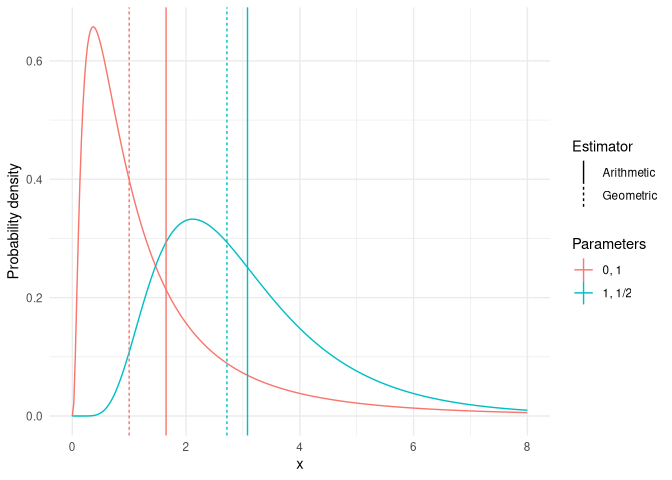

In [ ]:
library(ggplot2)

xx <- seq(0, 8, length.out=300)

dat <- data.frame(x = c(xx, xx),
                  dl = c(dlnorm(xx, 0, 1),
                         dlnorm(xx, 1, 1/2)),
                  pars = rep(c("0, 1", "1, 1/2"), c(300,300)))

pardat <- data.frame(pars = rep(c("0, 1", "1, 1/2"), c(2,2)),
                     method = rep(c("Arithmetic", "Geometric"),
                                  2),
                     value = exp(c(0+1/2*1^2, 0,
                               1+1/2*1/2^2, 1)))

ggplot(dat) +
  geom_line(aes(x=x, y=dl, group=pars, colour=pars)) +
  geom_vline(aes(xintercept=value, lty=method, group=pars,
                 colour=pars), data=pardat) +
  labs(x="x", y="Probability density", colour="Parameters",
       lty="Estimator") +
  theme_minimal()

Similarly, we define the arithmetic and geometric standard deviations as
follows:

This is all fine in the simple case where we’re just estimating the
distribution parameters, with no covariates involved. What about when we
want to use covariates for prediction?

## log-normal response in regression-like models

We may want to model the mean via some linear model, for example when
using a GLM or GAM. We decompose the mean as
$\mathbf{X}\boldsymbol{\beta}$, where $\mathbf{X}$ is an $n\times p$
design matrix and $\boldsymbol{\beta}$ is a $p$-vector of coefficients
to be estimated (where n is the number of observations).

In practice, one can simply assume that the log-response is normally
distributed and fit a GLM-a-like (GAM/GLMM/GAMM/etc) with a normal
distribution. This model is:

which is clearly modelling the geometric, rather than arithmetic mean
(equivalently, we are modelling the median). This naturally extends to
the case of random effects and therefore penalized smoothers (i.e.,
GLMMs, GAMs and GAMMs).

We can post hoc correct predictions to use the arithmetic mean using a
multivariate version of the corrections above. These corrections lead to
the following expressions:

where $g(\boldsymbol{\beta})=b^{X\boldsymbol{\beta}}$ if $b$ is the base
we are working in and $X$ is the design matrix for our model. $D$
indicates the derivative operator with respect to $\boldsymbol{\beta}$,
with powers of $D$ giving that order of derivative. $\Sigma$ is the
posterior covariance matrix for $\boldsymbol{\beta}$ (see, e.g. [Miller
(2025)](https://doi.org/10.1111/2041-210X.14498) for further explanation
of covariance matrices in the context of empirical Bayes modelling).

# Analysis of pollutant data

We now start our analysis. This code is based on examples by Mike Dunbar
to illustrate fitting a GAMM with censored normal family to water
quality time series from multiple sites ([Harmonised Monitoring Scheme
sites for
England](https://en.wikipedia.org/wiki/Harmonised_monitoring_scheme)) to
look at smoothed trends over time and the effects of seasonality. For
each determinand we fit a separate model where site is a random effect
and we use two temporal smoothers.

We begin by loading the requisite packages.

In [ ]:
library(dplyr)
library(ggplot2)
library(mgcv)
library(tictoc)
library(lubridate)
library(tidyr)
library(purrr)
library(gratia)
library(stringr)

There are some non-CRAN packages required which we can install directly
from GitHub, then load:

In [ ]:
# for nice scales
remotes::install_github("christyray/sciscales")
library(sciscales)

# for the censored log normal helper functions
remotes::install_github("dill/mgcvUtils")
library(mgcvUtils)

Michael Dunbar at the Environment Agency pre-prepared data for this
analysis using open data from EA (extracted using EA APIs).

In [ ]:
# created in data_prep.R
load('data/HMS_open_data.rda')
head(samples)

# A tibble: 6 × 15
  sample.samplingPoint.notation sample.samplingPoint.label sample.sampleDateTime
  <chr>                         <chr>                      <dttm>               
1 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2000-01-11 10:16:00  
2 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2000-01-11 10:16:00  
3 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2000-01-11 10:16:00  
4 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2008-05-02 13:30:00  
5 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2008-05-02 13:30:00  
6 AN-26M31                      HUNDRED FOOT RIVER EARITH… 2008-05-02 13:30:00  
# ℹ 12 more variables: determinand.label <chr>, determinand.definition <chr>,
#   determinand.notation <chr>, resultQualifier.notation <chr>, result <dbl>,
#   codedResultInterpretation.interpretation <lgl>,
#   determinand.unit.label <chr>, sample.sampledMaterialType.label <chr>,
#   sample.isComplianceSample <lgl>, sample.purpose

This data has four determinands, for brevity here we’ll just look at
one: nitrate (where `determinand.notation==0117` in our data).

In [ ]:
samples <- samples |>
  filter(determinand.notation == "0117")

## Data checking

Plotting the data, we can see how the limit of detection (red) changes
over time.[1]

[1] The censored data is coded in the `resultQualifier.notation` columns
with a `<`.

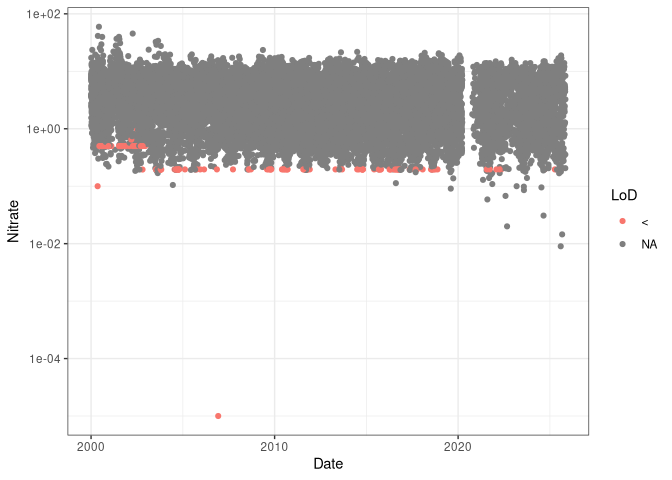

In [ ]:
samples |>
  ggplot() +
  geom_point(aes(x = sample.sampleDateTime,
                 y = result,
                 group = sample.samplingPoint.notation,
                 colour = resultQualifier.notation)) +
  scale_y_log10() +
  labs(x="Date", y="Nitrate", colour="LoD") +
  theme_bw()

If we tabulate the LoD values we can see one is certainly more common
than the others:

In [ ]:
samples |>
  # can comment out
  filter(resultQualifier.notation == '<') |>
  group_by(result) |>
  summarise(n = n())

# A tibble: 9 × 2
   result     n
    <dbl> <int>
1 0.00001     1
2 0.1         1
3 0.192       1
4 0.195       8
5 0.196      90
6 0.5        32
7 0.504       1
8 0.648       1
9 0.996       1

The predominant LoD in the original data is 0.196 although some earlier
data it is 0.5. For simplicity in this analysis, we use 0.196.

## Final data prep

When we log-transform we can’t use zero as the lower bound for censored
values we just choose a very small value. We use a value 2 orders of
magnitude below lowest limit of detection.

In [ ]:
nearly.zero <- 0.000001
log.zero <- log10(nearly.zero)

Create some extra columns, ensure categorical variables are factors.

In [ ]:
samples <-
  samples |>
  mutate(DATE = date(sample.sampleDateTime),
         year = year(DATE),
         month = month(DATE),
         samplingPoint.F = as.factor(sample.samplingPoint.notation),
         det.code.desc = paste(determinand.notation, determinand.label, sep = '-'),
         DATE_DEC = round(decimal_date(DATE),2),
         MEAS_SIGN = replace_na(resultQualifier.notation, '='),
         log.meas.upper = log10(result + nearly.zero),
         log.meas.lower = if_else(MEAS_SIGN == '<', log.zero, log.meas.upper),
         censored = ifelse(MEAS_SIGN == '<', TRUE, FALSE),
         # these two lines are because for the not artificially censored data,
         # the ..original columns won't be populated yet
         result.original = result,
         qualifier.original = resultQualifier.notation
         )

Finally we create the response matrix, which is two columns (if entries
are the same there was no censoring, if they are different there was
censoring; see `?mgcv::cnorm`):

In [ ]:
samples$y <- cbind(samples$log.meas.lower, samples$log.meas.upper)
head(samples$y)

          [,1]      [,2]
[1,] 1.1172713 1.1172713
[2,] 0.8656961 0.8656961
[3,] 0.7259117 0.7259117
[4,] 0.7686382 0.7686382
[5,] 0.7558749 0.7558749
[6,] 0.7810370 0.7810370

Note that although we pass a matrix to `mgcv` as the response, we only
have a univariate response variable, the second column is only for
indicating censoring to the code.

# Modelling

We can now fit our generalized additive model. We want to fit a model of
the following form:

where $i$ indexes the observations which have nitrate level $Y_i$ on
date $t_i$ in month $m_i$ and station $z_i$ (where $\beta_{z}$ is a
random intercept for station $z$). Generic smoothers are denoted $s()$.
We want to look at any common trend across our monitoring sites, which
will be in the terms $s(t_i)$ and $s(m_i)$. We use $b=10$ for this
modelling, though any scientifically appropriate base would be usable
with these functions/methods.

In practice we fit:

Here we will use [`bam` and
fREML](https://doi.org/10.1080/01621459.2016.1195744) for speed here to
show that these methods work with large data approaches too.

We need to setup knots for the monthly smoother. Note that we just need
to specify the first and last knot, then `mgcv` will fill in
evenly-spaced knots in that range. See [this useful blog post by Gavin
Simpson about cyclic
smoothing](https://fromthebottomoftheheap.net/2014/05/09/modelling-seasonal-data-with-gam/).

In [ ]:
# for month cyclic cubic spline
sknots <- list(month=c(0.5, 12.5))

We can now fit the model

In [ ]:
b <- bam(y ~ s(DATE_DEC, bs = 'cr') +
             s(month, bs = 'cc') +
             s(samplingPoint.F, bs = 're'),
         method = 'fREML',
         family = clognorm(base=10),
         knots = sknots,
         data = samples)


b_uncorrected <- bam(y ~ s(DATE_DEC, bs = 'cr') +
                         s(month, bs = 'cc') +
                         s(samplingPoint.F, bs = 're'),
                         method = 'fREML',
                         family = cnorm(),
                         knots = sknots,
                         data = samples)

Looking at a summary output as usual. In particular we can see that we
used the new `clognorm` family (see `Family:` line). This shows the base
(10) and the standard deviation result (compare to the second summary
from the `cnorm` model).

In [ ]:
summary(b)


Family: clog10norm(0.207) 
Link function: identity 

Formula:
y ~ s(DATE_DEC, bs = "cr") + s(month, bs = "cc") + s(samplingPoint.F, 
    bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.44305    0.05678   7.803 6.35e-15 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf Ref.df       F p-value    
s(DATE_DEC)         8.782  8.986   64.05  <2e-16 ***
s(month)            6.711  8.000  328.23  <2e-16 ***
s(samplingPoint.F) 50.957 51.000 1260.35  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.433   Deviance explained = 77.4%
fREML =  79415  Scale est. = 1         n = 19596


Family: cnorm(0.207) 
Link function: identity 

Formula:
y ~ s(DATE_DEC, bs = "cr") + s(month, bs = "cc") + s(samplingPoint.F, 
    bs = "re")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.44305    0.05678   7.803 6.35e-15 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf Ref.df       F p-value    
s(DATE_DEC)         8.782  8.986   64.05  <2e-16 ***
s(month)            6.711  8.000  328.23  <2e-16 ***
s(samplingPoint.F) 50.957 51.000 1260.35  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.433   Deviance explained = 77.4%
fREML =  79415  Scale est. = 1         n = 19596

We note there are no differences in the estimated degrees of freedom
(`edf`), fREML score etc.

# Making predictions

We want to make some predictions over the date range 2000 to 2025 (no
extrapolation into the future). We are interested in patterns with and
without the seasonality (month) component. We are not interested in
per-site predictions (and we’ll exclude that effect in our predictions),
so for now we just use one site.

In [ ]:
predgrid <- data.frame(date = seq(ymd("2021-01-01"), ymd("2025-09-30"), by=1),
                       samplingPoint.F = samples$samplingPoint.F[1])
predgrid$DATE_DEC <- decimal_date(predgrid$date)
# get decimal months for interpolation
predgrid$month <- (decimal_date(predgrid$date)-year(predgrid$date)) * 12

In the above code we used the `clognorm` response family, which is
provided in the `mgcvUtils` package. Internally this package fits the
same model as `cnorm` but implements a prediction method that corrects
the results, provided we use the `type="response"` argument to
`predict`.

All this means that we can use the usual `predict` method and get the
corrected predictions transparently (provided we ask for results on the
response scale). For example:

In [ ]:
predgrid$pred <- predict(b, predgrid, type="response",
                         exclude=c("s(samplingPoint.F)", "s(DATE_DEC)"))

We can add a confidence band around this plot by manually calculating
the upper and lower bounds, but `mgcvUtils` also provides a function to
do this for you in an analogous way to the
[`gratia`](https://gavinsimpson.github.io/gratia/) package, via the
`fitted_values_clognorm` function[1].

[1] Note that the `fitted_values` function in `gratia` will not work
with the `clognorm` family at this time.

In [ ]:
fv <- fitted_values_clognorm(b, predgrid, scale="response",
                             exclude="s(samplingPoint.F)")
head(fv)

  .row       date samplingPoint.F DATE_DEC      month  .fitted         .se
1    1 2021-01-01        AN-26M31 2021.000 0.00000000 2.940149 0.002760783
2    2 2021-01-02        AN-26M31 2021.003 0.03287671 2.944586 0.002765074
3    3 2021-01-03        AN-26M31 2021.005 0.06575342 2.948817 0.002769199
4    4 2021-01-04        AN-26M31 2021.008 0.09863014 2.952850 0.002773164
5    5 2021-01-05        AN-26M31 2021.011 0.13150685 2.956694 0.002776974
6    6 2021-01-06        AN-26M31 2021.014 0.16438356 2.960360 0.002780632
  .lower_ci .upper_ci
1  2.903744  2.977011
2  2.908070  2.981561
3  2.912194  2.985900
4  2.916124  2.990037
5  2.919871  2.993982
6  2.923443  2.997743

We can compare the trend from the corrected predictions alongside the
uncorrected. In this case we first must construct covariance matrix for
the transformed standard error (using the delta method):

In [ ]:
fv_gm <- fitted_values(b_uncorrected, predgrid, exclude="s(samplingPoint.F)")

# partial correction
Xp <- predict(b_uncorrected, predgrid, type="lpmatrix")
tpred <- 10^predict(b_uncorrected, predgrid, type="response")
base <- 10
Dg <- log(base) * sweep(Xp, 1, tpred, "*")
fv_gm$.se <- sqrt(diag(tcrossprod(Dg%*%vcov(b_uncorrected), Dg))/length(b_uncorrected$y))

crit <- gratia:::coverage_normal(0.95)
fv_gm[[".lower_ci"]] <- fv_gm[[".fitted"]] - (crit * fv_gm[[".se"]])
fv_gm[[".upper_ci"]] <- fv_gm[[".fitted"]] + (crit * fv_gm[[".se"]])

We can now compare these graphically:

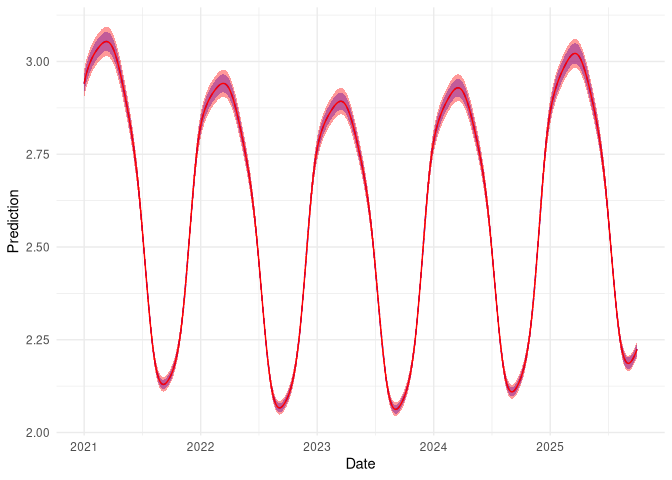

In [ ]:
ggplot(fv) +
  geom_ribbon(aes(x=DATE_DEC, ymin=10^.lower_ci, ymax=10^.upper_ci),
              fill="blue", alpha=0.4, data=fv_gm) +
  geom_line(aes(x=DATE_DEC, y=10^.fitted), lty=2, data=fv_gm, colour="blue") +
  geom_ribbon(aes(x=DATE_DEC, ymin=.lower_ci, ymax=.upper_ci),
              fill="red", alpha=0.4) +
  geom_line(aes(x=DATE_DEC, y=.fitted), colour="red") +
  labs(x="Date", y="Prediction") +
  theme_minimal()

Here the red line/band indicate the corrected predictions with
uncertainty, blue is the uncorrected predictions. We can’t see much
difference in the mean estimates (red line overlaps blue) but there is a
considerable reduction in uncertainty.

# Conclusion

We can now correct for the bias incurred by using a geometric mean
estimator when we really want to use an arithmetic mean. To do this we
use the `clognorm` family as provided by the `mgcvUtils` package. Once
we’ve fitted the model, we can use the standard `predict` method or to
save time, we can use `fitted_values_clognorm`.